In [24]:
# Upload kaggle.json
from google.colab import files
files.upload()  # Choose the kaggle.json file you downloaded


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ahmedttarek","key":"a5e52ff9f058d692934ba534638af4cf"}'}

In [25]:
# Create the required directory and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [84]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import shap


In [11]:
# Load the dataset
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")


Using Colab cache for faster access to the 'telco-customer-churn' dataset.


In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [44]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [45]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [46]:
data.duplicated().sum()

np.int64(0)

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [78]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
data_clean = data.copy()

data_clean["TotalCharges"] = pd.to_numeric(data_clean["TotalCharges"], errors="coerce")

print("Missing values after converting TotalCharges:")
data_clean.isna().sum()[data_clean.isna().sum() > 0]

Missing values after converting TotalCharges:


,0
TotalCharges,11


In [52]:
data_clean[data_clean["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [53]:
data_clean["TotalCharges"] = data_clean["TotalCharges"].fillna(0)

print("Remaining missing values:", data_clean.isna().sum().sum())

Remaining missing values: 0


# **Exploratory Data Analysis**


In [54]:
data_clean["Churn_Flag"] = data_clean["Churn"].map({"Yes": 1, "No": 0})

data_clean[["Churn", "Churn_Flag"]].head()

,Churn,Churn_Flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [56]:
churn_counts = data_clean["Churn"].value_counts()
churn_rate = data_clean["Churn_Flag"].mean()

print(churn_counts)
print(f"\nOverall churn rate: {churn_rate:.2%}")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.54%


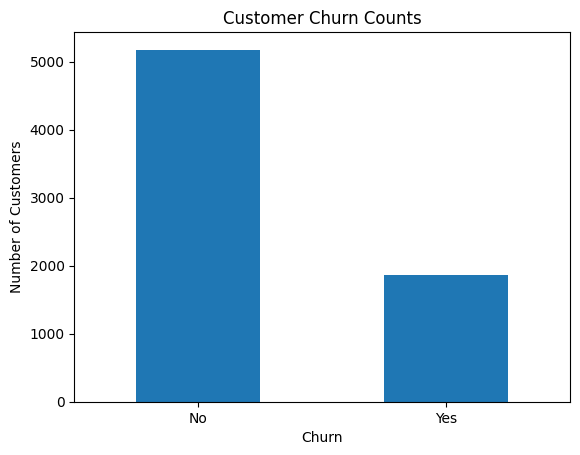

In [57]:
churn_counts.plot(kind="bar")
plt.title("Customer Churn Counts")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [59]:
contract_churn = (
    data_clean
    .groupby("Contract")["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
    .sort_values("Churn_Rate", ascending=False)
)

contract_churn["Churn_Rate_%"] = contract_churn["Churn_Rate"] * 100

contract_churn[["Customer_Count", "Churn_Rate_%"]]

,Customer_Count,Churn_Rate_%
Contract,,
Month-to-month,3875,42.709677
One year,1473,11.269518
Two year,1695,2.831858


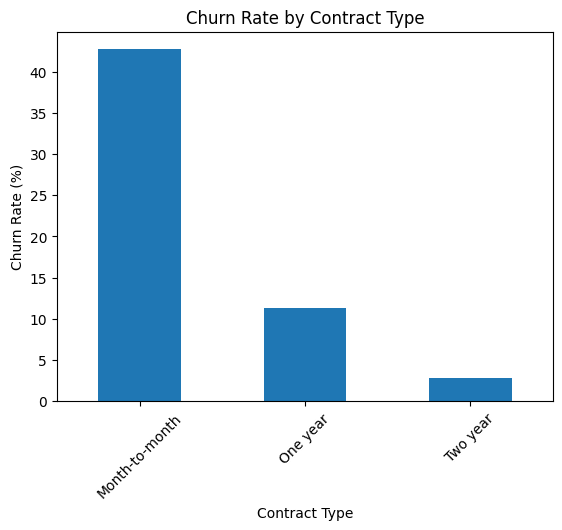

In [60]:
contract_churn["Churn_Rate_%"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

#### Churn by Tenure

In [61]:
data_clean["Tenure_Group"] = pd.cut(
    data_clean["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

tenure_churn = (
    data_clean
    .groupby("Tenure_Group", observed=False)["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
)

tenure_churn["Churn_Rate_%"] = tenure_churn["Churn_Rate"] * 100

tenure_churn[["Customer_Count", "Churn_Rate_%"]]

,Customer_Count,Churn_Rate_%
Tenure_Group,,
0-12 months,2186,47.438243
13-24 months,1024,28.710938
25-48 months,1594,20.388959
49-72 months,2239,9.513176


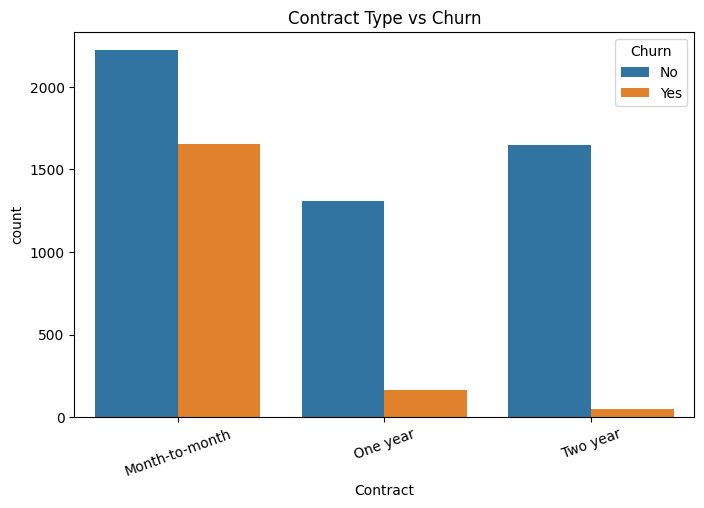

In [79]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=data_clean
)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

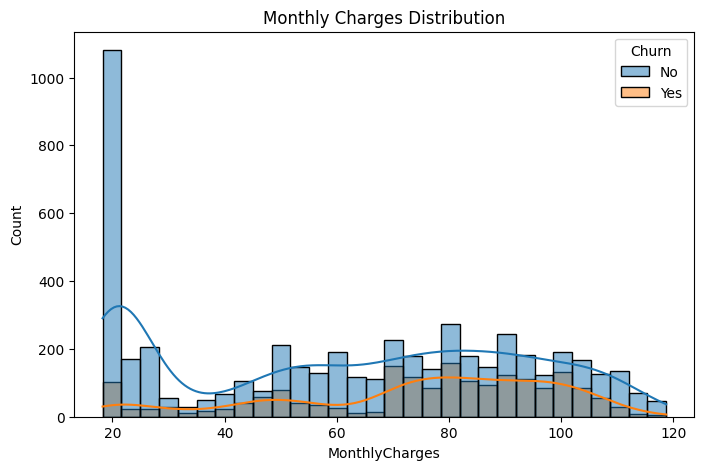

In [80]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data_clean,
    x='MonthlyCharges',
    hue='Churn',
    kde=True,
    bins=30
)

plt.title("Monthly Charges Distribution")
plt.show()

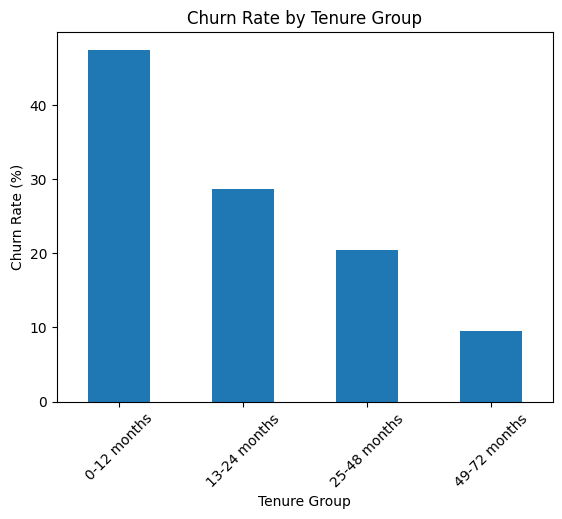

In [62]:
tenure_churn["Churn_Rate_%"].plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

#### Churn by Monthly Charges

In [63]:
data_clean.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


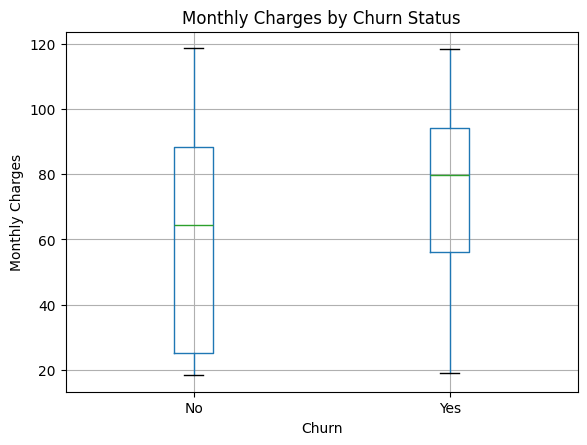

In [64]:
data_clean.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [65]:
internet_churn = (
    data_clean
    .groupby("InternetService")["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
    .sort_values("Churn_Rate", ascending=False)
)

internet_churn["Churn_Rate_%"] = internet_churn["Churn_Rate"] * 100

internet_churn[["Customer_Count", "Churn_Rate_%"]]

,Customer_Count,Churn_Rate_%
InternetService,,
Fiber optic,3096,41.892765
DSL,2421,18.959108
No,1526,7.404980


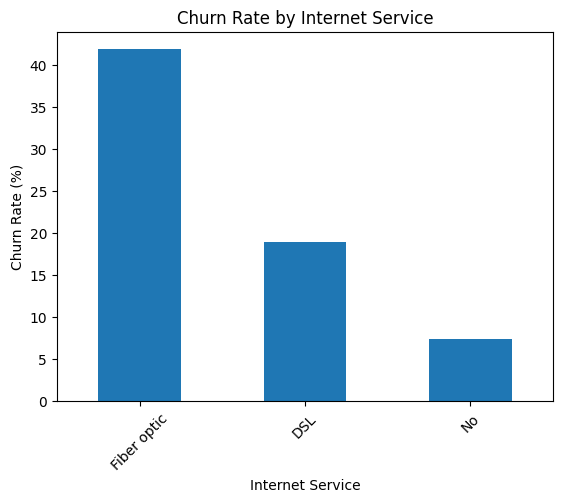

In [66]:
internet_churn["Churn_Rate_%"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [67]:
payment_churn = (
    data_clean
    .groupby("PaymentMethod")["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
    .sort_values("Churn_Rate", ascending=False)
)

payment_churn["Churn_Rate_%"] = payment_churn["Churn_Rate"] * 100

payment_churn[["Customer_Count", "Churn_Rate_%"]]

,Customer_Count,Churn_Rate_%
PaymentMethod,,
Electronic check,2365,45.285412
Mailed check,1612,19.106700
Bank transfer (automatic),1544,16.709845
Credit card (automatic),1522,15.243101


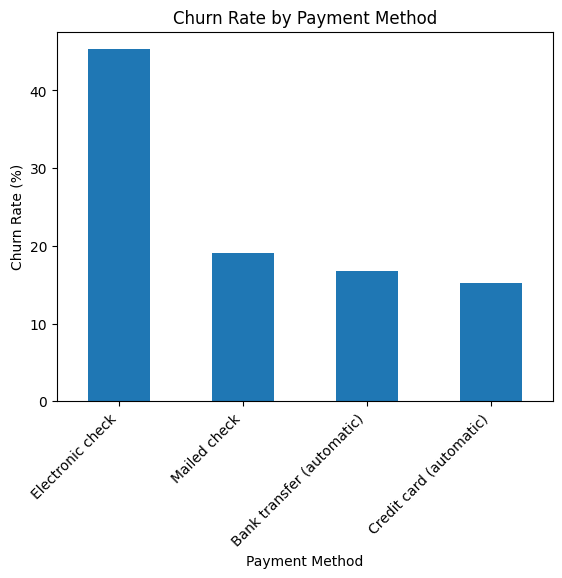

In [68]:
payment_churn["Churn_Rate_%"].plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

# **Initial EDA Findings**

In [69]:
def churn_summary(column):
    summary = (
        data_clean
        .groupby(column)["Churn_Flag"]
        .agg(Customer_Count="count", Churn_Rate="mean")
        .sort_values("Churn_Rate", ascending=False)
    )

    summary["Churn_Rate_%"] = summary["Churn_Rate"] * 100

    return summary[["Customer_Count", "Churn_Rate_%"]]

In [70]:
churn_summary("OnlineSecurity")

,Customer_Count,Churn_Rate_%
OnlineSecurity,,
No,3498,41.766724
Yes,2019,14.611194
No internet service,1526,7.404980


In [71]:
churn_summary("TechSupport")

,Customer_Count,Churn_Rate_%
TechSupport,,
No,3473,41.635474
Yes,2044,15.166341
No internet service,1526,7.404980


In [72]:
churn_summary("OnlineBackup")

,Customer_Count,Churn_Rate_%
OnlineBackup,,
No,3088,39.928756
Yes,2429,21.531494
No internet service,1526,7.404980


In [73]:
churn_summary("DeviceProtection")

,Customer_Count,Churn_Rate_%
DeviceProtection,,
No,3095,39.127625
Yes,2422,22.502064
No internet service,1526,7.404980


In [74]:
churn_summary("PaperlessBilling")

,Customer_Count,Churn_Rate_%
PaperlessBilling,,
Yes,4171,33.565092
No,2872,16.330084


In [75]:
data_clean["Risk_Factor_Count"] = 0

data_clean["Risk_Factor_Count"] += (data_clean["Contract"] == "Month-to-month").astype(int)
data_clean["Risk_Factor_Count"] += (data_clean["tenure"] <= 12).astype(int)
data_clean["Risk_Factor_Count"] += (data_clean["InternetService"] == "Fiber optic").astype(int)
data_clean["Risk_Factor_Count"] += (data_clean["PaymentMethod"] == "Electronic check").astype(int)
data_clean["Risk_Factor_Count"] += (data_clean["MonthlyCharges"] > data_clean["MonthlyCharges"].median()).astype(int)

risk_churn = (
    data_clean
    .groupby("Risk_Factor_Count")["Churn_Flag"]
    .agg(Customer_Count="count", Churn_Rate="mean")
)

risk_churn["Churn_Rate_%"] = risk_churn["Churn_Rate"] * 100

risk_churn[["Customer_Count", "Churn_Rate_%"]]

,Customer_Count,Churn_Rate_%
Risk_Factor_Count,,
0,1376,2.543605
1,1150,8.347826
2,1762,20.488082
3,1197,34.837093
4,1018,56.188605
5,540,71.851852


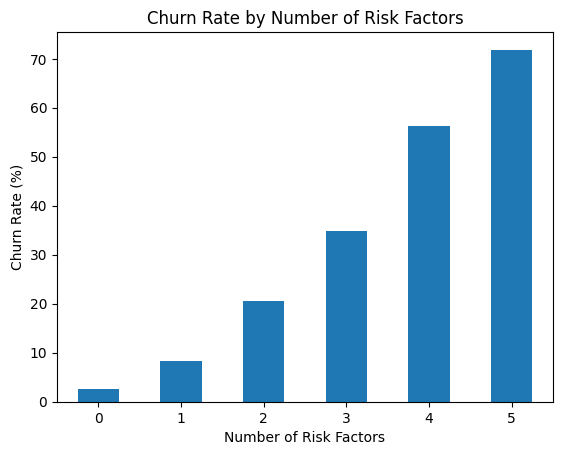

In [76]:
risk_churn["Churn_Rate_%"].plot(kind="bar")

plt.title("Churn Rate by Number of Risk Factors")
plt.xlabel("Number of Risk Factors")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

# Churn Heatmap

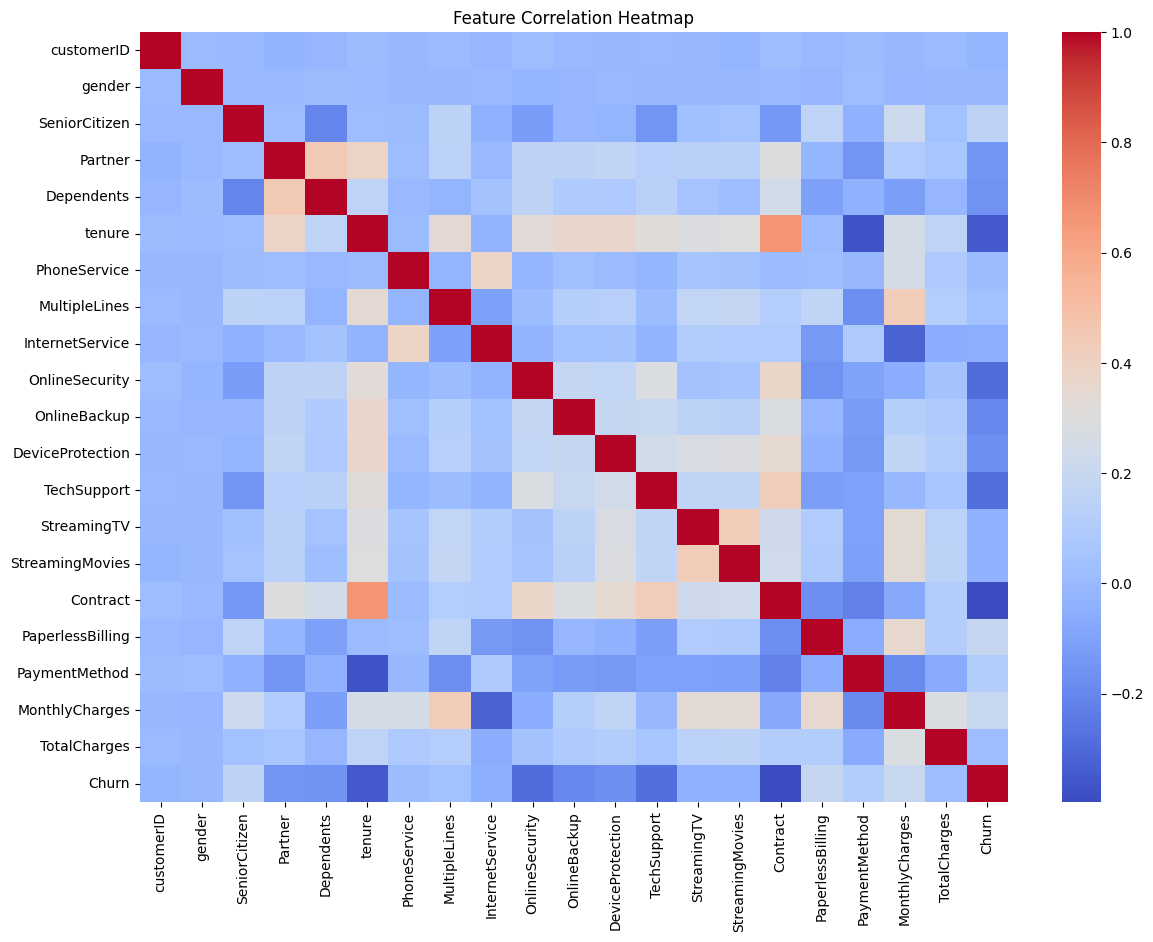

In [92]:
temp = data.copy()

for col in temp.select_dtypes('object').columns:
    temp[col] = LabelEncoder().fit_transform(temp[col])

plt.figure(figsize=(14,10))
sns.heatmap(
    temp.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

# Revenue Analysis

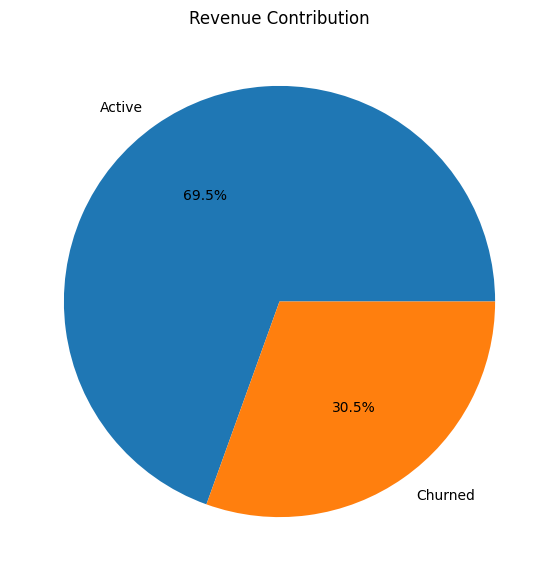

In [93]:
churned_revenue = data_clean[data_clean['Churn']=='Yes']['MonthlyCharges'].sum()
active_revenue = data_clean[data_clean['Churn']=='No']['MonthlyCharges'].sum()
plt.figure(figsize=(7,7))

plt.pie(
    [active_revenue,churned_revenue],
    labels=['Active','Churned'],
    autopct='%1.1f%%'
)

plt.title("Revenue Contribution")
plt.show()

# **Service Feature Findings**
Service-related features show clear churn patterns. Customers without online security, tech support, online backup, or device protection have noticeably higher churn rates than customers who have those services.

The strongest service-related churn signals are online security and tech support. Customers without online security churn at about 41.77%, compared with about 14.61% for customers with online security. Customers without tech support churn at about 41.64%, compared with about 15.17% for customers with tech support.

This suggests that customers who receive more support, protection, or account value from the company may be more likely to stay.

# **Risk Factor Analysis**
A simple risk factor score was created using five churn-related conditions:

  * Month-to-month contract
  * Tenure of 12 months or less
  * Fiber optic internet service
  * Electronic check payment method
  * Monthly charges above the median


The churn rate increases sharply as the number of risk factors increases. Customers with no risk factors churn at only 2.54%, while customers with all five risk factors churn at 71.85%.

This does not replace a machine learning model, but it provides a clear business-friendly way to explain churn risk. It shows that churn is not driven by one single variable. Instead, customers become much more likely to churn when multiple risk factors appear together.

# **EDA Conclusion**
This notebook cleaned the Telco Customer Churn dataset and explored the main factors associated with customer churn.

The overall churn rate is 26.54%. The analysis found that churn is especially high among month-to-month customers, newer customers, fiber optic customers, electronic check users, customers with higher monthly charges, and customers without support or protection services.

The most important early findings are:

* Month-to-month customers have much higher churn than one-year or two-year contract customers.
* New customers are at greater risk, especially those with 0-12 months of tenure.
* Churned customers tend to have higher monthly charges.
* Fiber optic customers and electronic check users show high churn rates.
* Customers without online security or tech support are more likely to churn.
* Churn risk increases sharply when multiple risk factors are combined.

These findings will guide the next stage of the project, where customer segments and business recommendations will be developed before building machine learning models to predict churn.

In [77]:
data_clean.to_csv("telco_churn_cleaned.csv", index=False)

print("Cleaned dataset saved as telco_churn_cleaned.csv")
print("Final shape:", data_clean.shape)

Cleaned dataset saved as telco_churn_cleaned.csv
Final shape: (7043, 24)


# **FEATURE ENGINEERING**

In [94]:
data_clean['CLV'] = data_clean['MonthlyCharges'] * data_clean['tenure']

In [95]:
data_clean['AvgMonthlySpend'] = (
    data_clean['TotalCharges'] /
    (data_clean['tenure'] + 1)
)

In [96]:
data_clean['Churn'] = data_clean['Churn'].map({
    'No':0,
    'Yes':1
})

In [116]:
le = LabelEncoder()

# Encode all categorical columns, including 'object' and 'category' dtypes
for col in data_clean.select_dtypes(include=['object', 'category']).columns:
    data_clean[col] = le.fit_transform(data_clean[col])

# **TRAIN TEST SPLIT**

In [118]:
X = data_clean.drop(['Churn', 'customerID', 'Churn_Flag'], axis=1)
y = data_clean['Churn']

# Label encode 'Tenure_Group' as it's a categorical feature
# This was previously removed but is essential as it's a 'category' dtype missed by the 'object' dtype encoder.
le_tenure = LabelEncoder()
X['Tenure_Group'] = le_tenure.fit_transform(X['Tenure_Group'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# MODEL **TRAINING**

# Logistic Regression


In [119]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



# Random Forest

In [120]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



# XGBoost

In [121]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



# **MODEL COMPARISON**

In [122]:
models = ['Logistic','Random Forest','XGBoost']

scores = [
    accuracy_score(y_test,lr_pred),
    accuracy_score(y_test,rf_pred),
    accuracy_score(y_test,xgb_pred)
]

comparison = pd.DataFrame({
    'Model':models,
    'Accuracy':scores
})

comparison

,Model,Accuracy
0,Logistic,0.802697
1,Random Forest,0.786373
2,XGBoost,0.787793


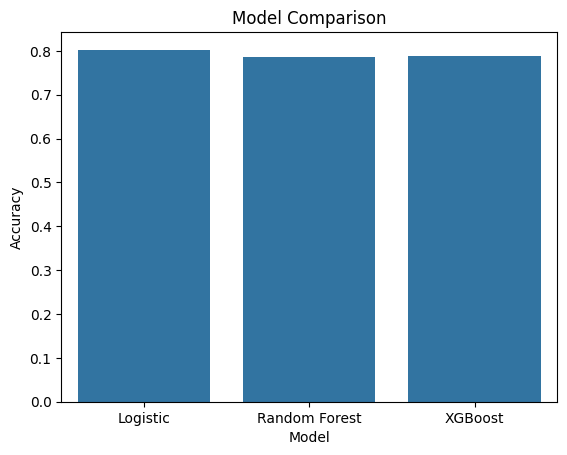

In [123]:
sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title("Model Comparison")
plt.show()

# **CONFUSION MATRIX**

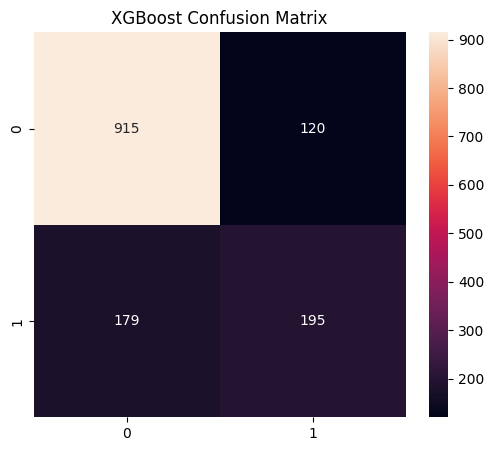

In [126]:
cm = confusion_matrix(y_test,xgb_pred)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("XGBoost Confusion Matrix")
plt.show()

# **ROC CURVE**

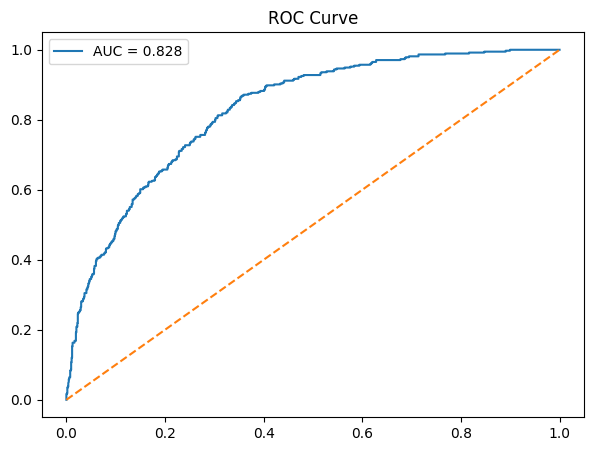

In [127]:
probs = xgb.predict_proba(X_test)[:,1]
fpr,tpr,_ = roc_curve(y_test,probs)
auc = roc_auc_score(y_test,probs)
plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--')

plt.legend()

plt.title("ROC Curve")
plt.show()

# **SHAP EXPLAINABILITY**

In [128]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Global Importance

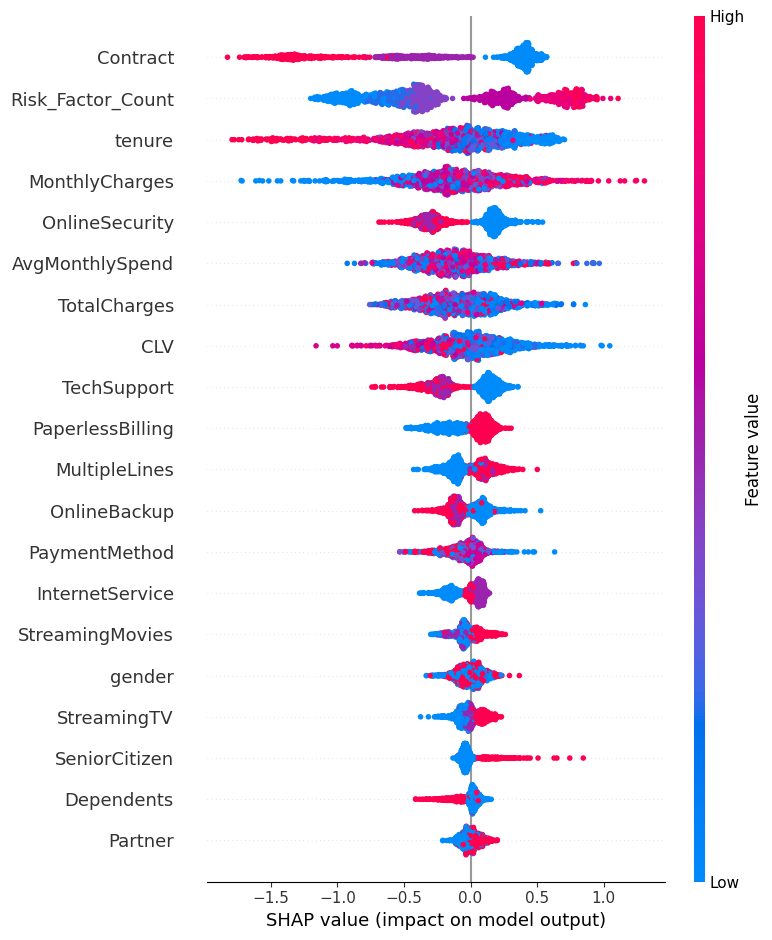

In [129]:
shap.summary_plot(
    shap_values,
    X_test
)

# Bar Plot

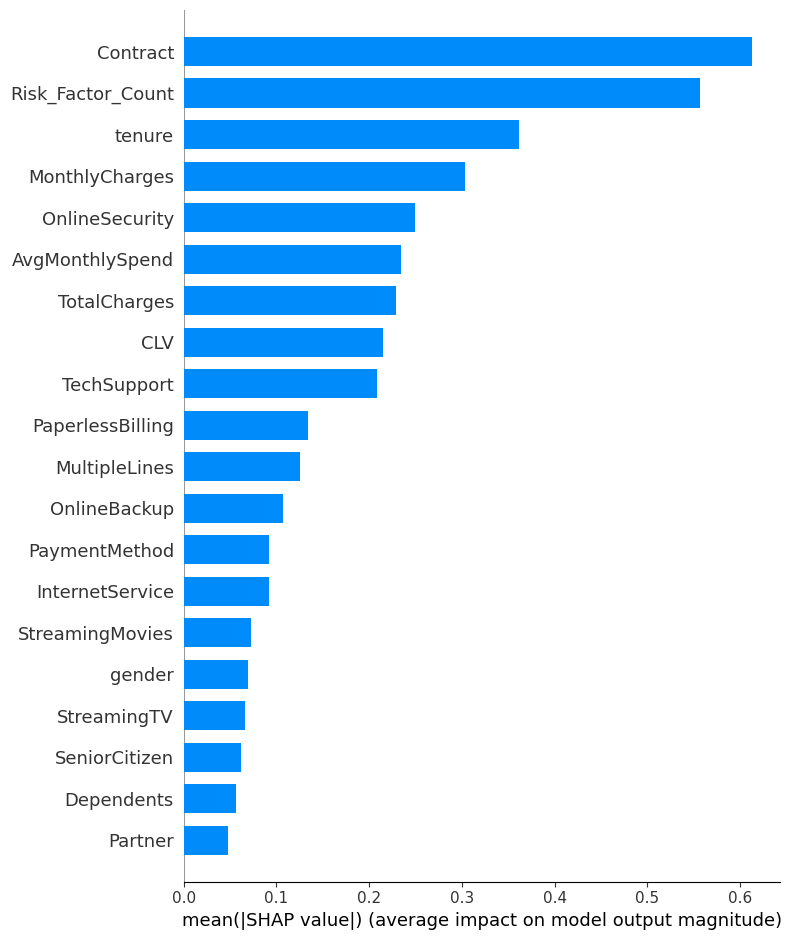

In [130]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

# **REVENUE AT RISK ANALYSIS**

In [131]:
risk_df = X_test.copy()
risk_df['Actual'] = y_test.values
risk_df['ChurnProbability'] = probs

risk_df['RevenueRisk'] = (
    risk_df['MonthlyCharges']
    * risk_df['ChurnProbability']
)

In [132]:
total_risk = risk_df['RevenueRisk'].sum()
print(f"Estimated Revenue At Risk: ${total_risk:,.2f}")

Estimated Revenue At Risk: $27,038.43


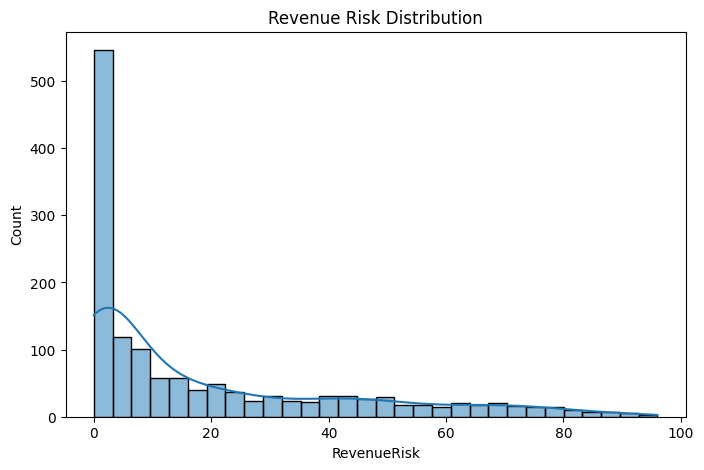

In [133]:
plt.figure(figsize=(8,5))

sns.histplot(
    risk_df['RevenueRisk'],
    bins=30,
    kde=True
)

plt.title("Revenue Risk Distribution")
plt.show()

# **CUSTOMER SEGMENTATION**

In [134]:
risk_df['RiskSegment'] = pd.cut(
    risk_df['ChurnProbability'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    include_lowest=True
)

print(risk_df[['ChurnProbability', 'RiskSegment']].head())

      ChurnProbability  RiskSegment
437           0.002692     Low Risk
2280          0.958689    High Risk
2235          0.048383     Low Risk
4460          0.376437  Medium Risk
3761          0.001438     Low Risk


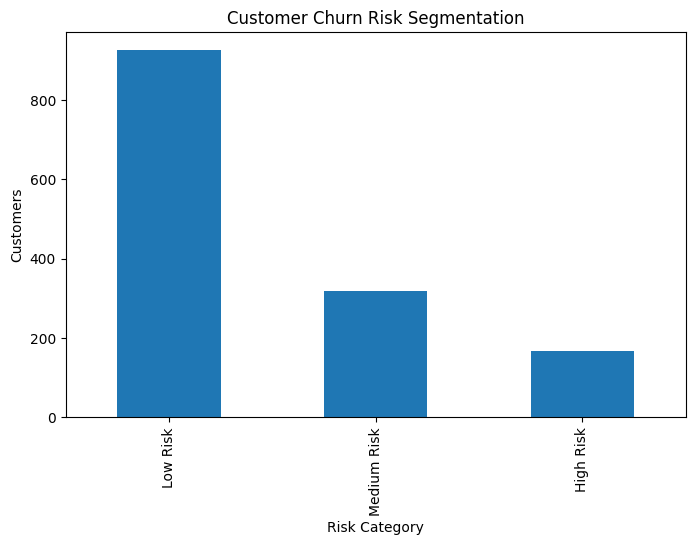

In [135]:
segment_counts = risk_df['RiskSegment'].value_counts()

plt.figure(figsize=(8,5))

segment_counts.plot(kind='bar')

plt.title("Customer Churn Risk Segmentation")
plt.ylabel("Customers")
plt.xlabel("Risk Category")

plt.show()

# **BUSINESS INSIGHTS**

In [136]:
top_risk = risk_df.sort_values(
    'RevenueRisk',
    ascending=False
)

top_risk.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Tenure_Group,Risk_Factor_Count,CLV,AvgMonthlySpend,Actual,ChurnProbability,RevenueRisk,RiskSegment
2280,0,1,0,0,8,1,2,1,0,0,...,100.15,908.55,0,4,801.20,100.950000,0,0.958689,96.012689,High Risk
85,1,0,0,0,9,1,2,1,0,2,...,99.30,918.75,0,4,893.70,91.875000,0,0.964643,95.789026,High Risk
2631,1,1,1,0,7,1,2,1,0,0,...,99.25,665.45,0,5,694.75,83.181250,1,0.955137,94.797366,High Risk
1568,1,1,0,0,11,1,2,1,0,2,...,111.40,1183.05,0,5,1225.40,98.587500,0,0.832798,92.773698,High Risk
6866,1,0,0,0,1,1,2,1,0,0,...,95.45,95.45,0,5,95.45,47.725000,1,0.969014,92.492345,High Risk
3380,1,1,1,0,1,1,2,1,0,0,...,95.10,95.10,0,5,95.10,47.550000,1,0.971245,92.365365,High Risk
4678,0,0,0,1,2,1,2,1,0,0,...,94.20,193.80,0,4,188.40,64.600000,1,0.970470,91.418275,High Risk
3822,0,0,1,1,6,1,2,1,0,2,...,94.05,518.75,0,4,564.30,74.107143,0,0.971253,91.346382,High Risk
1073,1,0,0,0,7,1,2,1,0,0,...,98.05,713.00,0,4,686.35,89.125000,1,0.922430,90.444294,High Risk
3956,0,0,1,0,6,1,2,1,0,2,...,105.30,545.20,0,5,631.80,77.885714,1,0.847775,89.270712,High Risk


# **Conclusion**

# Key Findings

XGBoost achieved the strongest predictive performance.

* Customers on month-to-month contracts exhibited significantly higher churn rates.

* Short-tenure customers were more likely to leave.

* Higher monthly charges increased churn probability.

* Electronic check users demonstrated elevated churn risk.

* SHAP analysis identified tenure, contract type, and monthly charges as the strongest drivers of churn.

* Revenue-at-risk analytics highlighted high-value customers requiring immediate retention interventions.

# Business Recommendations

1. Introduce loyalty incentives for low-tenure customers.

2. Promote long-term contract adoption.

3. Offer targeted discounts to high-risk customers.

4. Monitor high monthly charge segments.

5. Build proactive churn intervention campaigns.